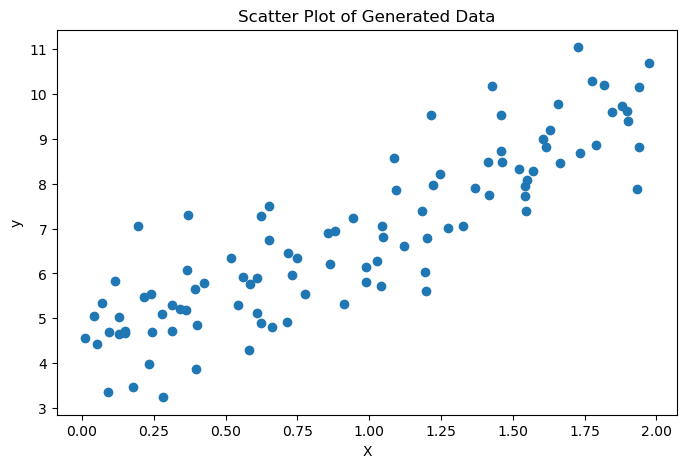

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
m = 100
X = 2 * np.random.rand(m,1)   #generates a m*n matrix from [0,2)
y = 4 + 3 * X + np.random.randn(m,1)   #fn(to add noise to the data) generates a mx1 matrix with std deviation 1 and mean 0

plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter Plot of Generated Data")

plt.show()

In [2]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
''' formula given on page 134 a_geron '''
''' called the closed form normal equation (for linear regression igso) '''

' called the closed form normal equation (for linear regression igso) '

In [3]:
#X_b
#X_b.T

In [4]:
theta_best

array([[4.21509616],
       [2.77011339]])

In [5]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)

In [6]:
X_new_b

array([[1., 0.],
       [1., 2.]])

In [7]:
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

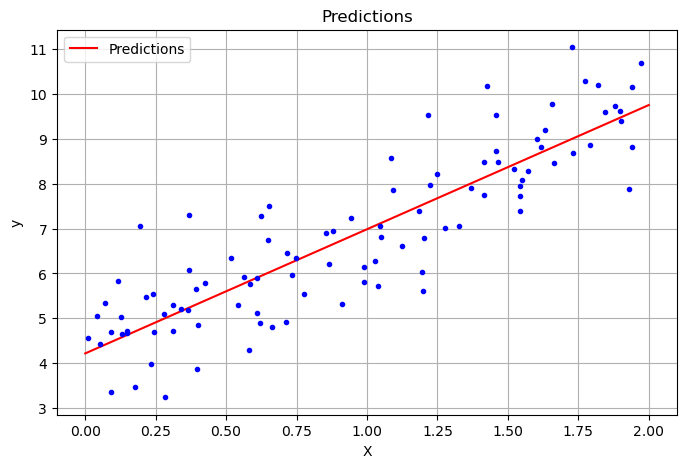

In [8]:
plt.figure(figsize = (8,5))

plt.plot(X_new, y_predict, "r-", label = "Predictions")
plt.plot(X, y, "b.")


plt.xlabel("X")
plt.ylabel("y")
plt.title("Predictions")

plt.legend()
plt.grid()

In [9]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
print(lin_reg.intercept_, lin_reg.coef_)
print(lin_reg.predict(X_new))

[4.21509616] [[2.77011339]]
[[4.21509616]
 [9.75532293]]


In [10]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond = 1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

In [11]:
np.linalg.pinv(X_b) @ y   #finds the pseudoInverseOf X_b and multiplies it with y

array([[4.21509616],
       [2.77011339]])

In [12]:
'''gradient descent'''
eta = 0.1 #learning rate
n_epochs = 1000 #total steps
m = len(X_b) #number of instances

np.random.seed(42)
theta = np.random.randn(2,1) # randomly initialized model parameters

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

In [13]:
theta

array([[4.21509616],
       [2.77011339]])

In [14]:
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0/ (t + t1)

np.random.seed(42)
theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

In [15]:
theta

array([[4.21076011],
       [2.74856079]])

In [16]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter = 1000, tol = 1e-5, penalty = None, eta0 = 0.01,
                       n_iter_no_change=100, random_state = 42)
sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

In [17]:
#polynomial regression
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m,1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m,1)

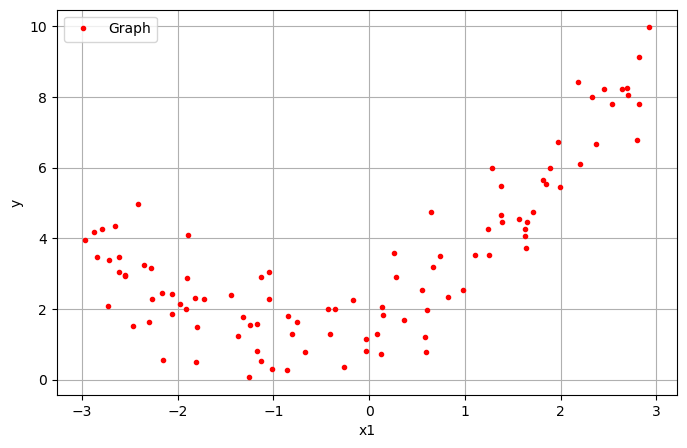

In [18]:
plt.figure(figsize = (8,5))

plt.plot(X,y, 'r.', label = 'Graph')

plt.xlabel("x1")
plt.ylabel("y")

plt.legend()
plt.grid()

In [19]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(include_bias = False, degree = 2)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [20]:
X_poly[0] # adds another feature which is the square(because of 2nd deg) of the 1st feature

array([-0.75275929,  0.56664654])

In [21]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.coef_, lin_reg.intercept_

(array([[0.93366893, 0.56456263]]), array([1.78134581]))

In [22]:
# the original function was y = (0.5) x^2 + (1) x + (2)

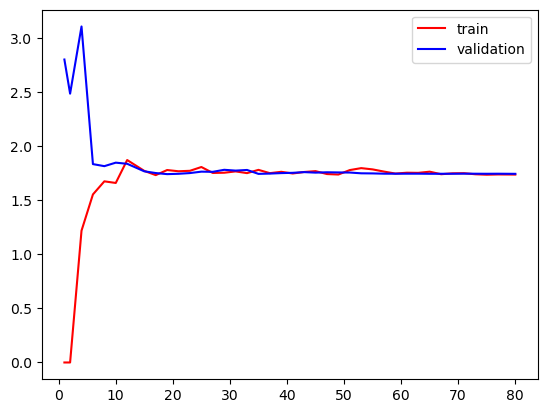

In [23]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes = np.linspace(0.01, 1, 40), cv = 5,
    scoring = "neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis = 1)
valid_errors = -valid_scores.mean(axis = 1)

plt.plot(train_sizes, train_errors, 'r-', label = 'train')
plt.plot(train_sizes, valid_errors, 'b-', label = 'validation')
plt.legend()

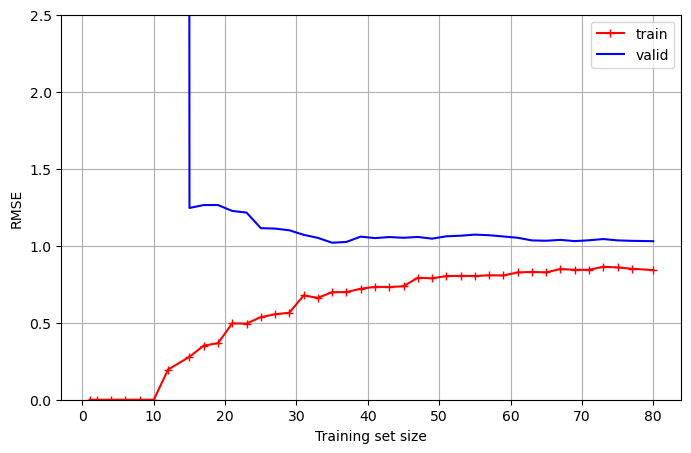

In [24]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree = 10, include_bias = False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes = np.linspace(0.01, 1.0, 40), cv = 5,
    scoring = 'neg_root_mean_squared_error')

train_errors = -train_scores.mean(axis = 1)
valid_errors = -valid_scores.mean(axis = 1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_errors, 'r-+', label = "train")
plt.plot(train_sizes, valid_errors, 'b-', label = "valid")
plt.xlabel("Training set size")
plt.ylabel("RMSE")

plt.ylim(0,2.5)
plt.legend()
plt.grid()

In [25]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha = 0.1, solver = "cholesky")
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])

array([[4.82899748]])

In [26]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(penalty = "l2", alpha = 0.1/m , tol = None,
                       max_iter = 1000, eta0 = 0.01, random_state = 42)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([4.82830117])

In [27]:
#lasso regresssion
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha = 0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([4.77621741])

In [28]:
#lasso using sgd
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(penalty = "l1", alpha = 0.1, tol = None,
                       max_iter = 1000, eta0 = 0.01, random_state = 42)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([4.77557733])

In [29]:
#elastic net regression
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha = 0.1, l1_ratio = 0.5)
elastic_net.fit(X,y)
elastic_net.predict([[1.5]])

array([4.78114505])

In [31]:
### beautiful_free_lunch method of early stopping
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
m = 100 
X = 6 * np.random.rand(m,1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m,1)

X_train, y_train = X[:m//2], y[:m//2 , 0]
X_valid, y_valid = X[m//2:], y[m//2: , 0]

preprocessing = make_pipeline(PolynomialFeatures(degree = 90, include_bias = False),
                                            StandardScaler())

X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)

sgd_reg = SGDRegressor(penalty = None, eta0 = 0.002, random_state = 42)
n_epochs = 500
best_valid_rmse = float('inf')
best_model = None

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

In [32]:
best_model

SGDRegressor(eta0=0.002, penalty=None, random_state=42)

In [35]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame = True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [36]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [37]:
iris.target.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [39]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[['petal width (cm)']]
y = (iris.target_names[iris.target] == 'virginica')
X_train, X_test , y_train, y_test = train_test_split(X,y, random_state = 42)

log_reg = LogisticRegression(random_state = 42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


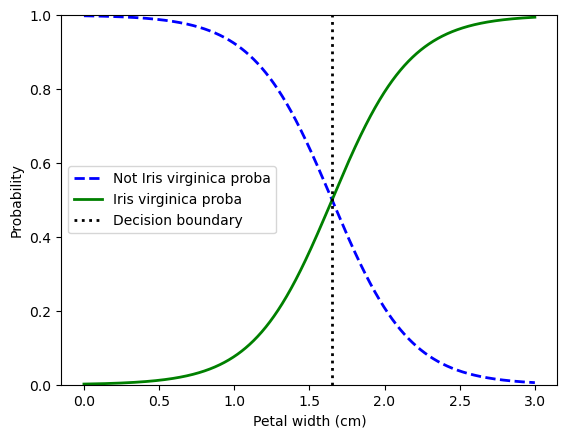

In [61]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)

decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2,
         label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

plt.xlabel("Petal width (cm)")  # optional, change as needed
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.ylim(0, 1)
plt.show()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,